# T3

In [55]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy.stats as st
import scipy.optimize as opt
import seaborn as sns
import math as mt
import sklearn.linear_model as skl
from skimage.io import imread, imsave
import statsmodels.api as sm


np.random.seed(42)
plt.style.use('ggplot')

$(\xi, \eta, \omega)$

In [56]:
X = np.array([[1, 0, 1],
              [0, 1, 5],
              [1, 1, 2]])

a) Найти уравнение линейной регрессии $\omega = a\xi + b\eta$

In [57]:
PSI = X[:, :-1]
Y = X[:, -1]
F = PSI.T @ PSI
F_inv = np.linalg.inv(F)
a_b = F_inv @ PSI.T @ Y
print("Уравнение линейной регрессии omega = a*xi + b*eta :")
print(f"omega = {a_b[0]:.3f}*xi + {a_b[1]:.3f}*eta")


Уравнение линейной регрессии omega = a*xi + b*eta :
omega = -0.333*xi + 3.667*eta


b) Найти уравнение $ridge$ регрессии $\omega = a\xi + b\eta$, построить график $CVSS$ и определить значение параметра регуляризации

In [67]:
def lam(i):
    return 10 * (i+1) / N

N = 10000
CVSS_ridge = np.zeros(N)
for i in range(N):
    for j in range(3):
        ridge = skl.Ridge(alpha=lam(i), fit_intercept=False, max_iter=10000).fit(np.delete(PSI, j, axis=0), np.delete(Y, j, axis=0))
        CVSS_ridge[i] += (Y[j] - np.dot(ridge.coef_, PSI[j])) ** 2

lam_opt_ridge = lam(np.argmin(CVSS_ridge))
print(f'λ_opt: {lam_opt_ridge}')

ridge_opt = skl.Ridge(alpha=lam_opt_ridge, fit_intercept=False, max_iter=10000).fit(PSI, Y)
print(f'a_opt = {ridge_opt.coef_[0]:.3f}, b_opt = {ridge_opt.coef_[1]:.3f}')

λ_opt: 1.506
a_opt = 0.312, b_opt = 1.908


c) Найти уравнение $lasso$ регрессии $\omega = a\xi + b\eta$, построить график $CVSS$ и определить значение параметра регуляризации

In [ ]:
def lam(i):
    return 10 * (i+1) / N

N = 1000
CVSS_lasso = np.zeros(N)
for i in range(N):
    for j in range(3):
        lasso = skl.Lasso(alpha=lam(i), fit_intercept=False, max_iter=10000).fit(np.delete(PSI, j, axis=0), np.delete(Y, j, axis=0))
        CVSS_lasso[i] += (Y[j] - np.dot(lasso.coef_, PSI[j])) ** 2

lam_opt_lasso = lam(np.argmin(CVSS_lasso))
print(f'λ_opt: {lam_opt_lasso}')

lasso_opt = skl.Lasso(alpha=lam_opt_lasso, fit_intercept=False, max_iter=10000).fit(PSI, Y)
print(f'a_opt = {lasso_opt.coef_[0]:.3f}, b_opt = {lasso_opt.coef_[1]:.3f}')

λ_opt: 1.5
a_opt = 0.000, b_opt = 1.250


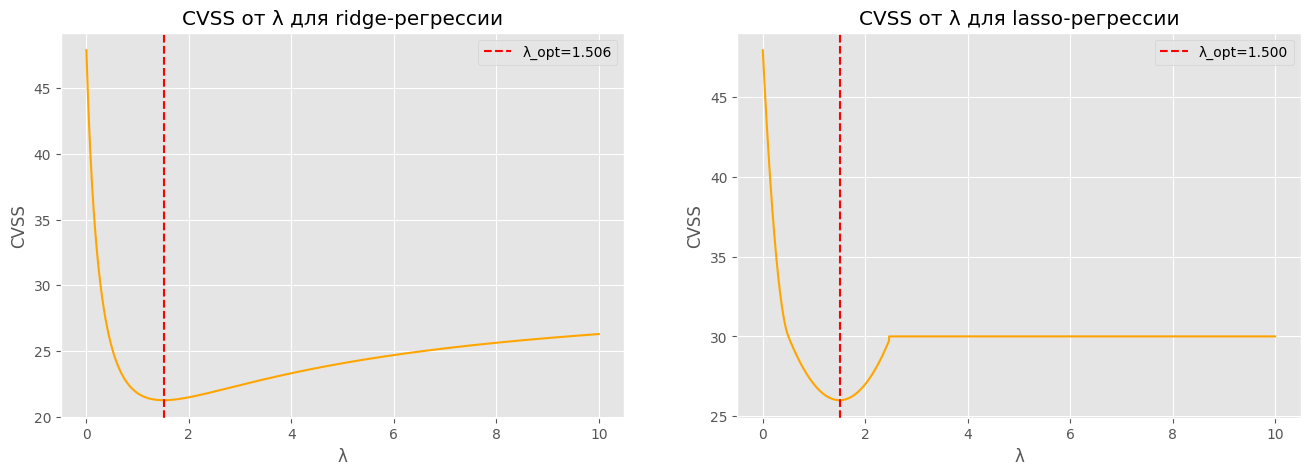

In [72]:
_, ax = plt.subplots(1, 2, figsize=(16, 5))

ax[0].plot([lam(i) for i in range(N)], CVSS_ridge, color = 'orange')
ax[0].axvline(x=lam_opt_ridge, color='red', linestyle='--', label=f'λ_opt={lam_opt_ridge:.3f}')
ax[0].set_title('CVSS от λ для ridge-регрессии')
ax[0].set_xlabel('λ')
ax[0].set_ylabel('CVSS')
ax[0].legend()

ax[1].plot([lam(i) for i in range(N)], CVSS_lasso, color = 'orange')
ax[1].axvline(x=lam_opt_lasso, color='red', linestyle='--', label=f'λ_opt={lam_opt_lasso:.3f}')
ax[1].set_title('CVSS от λ для lasso-регрессии')
ax[1].set_xlabel('λ')
ax[1].set_ylabel('CVSS')
ax[1].legend()

plt.show()

λ_opt (по кросс-валидации): 5.9964


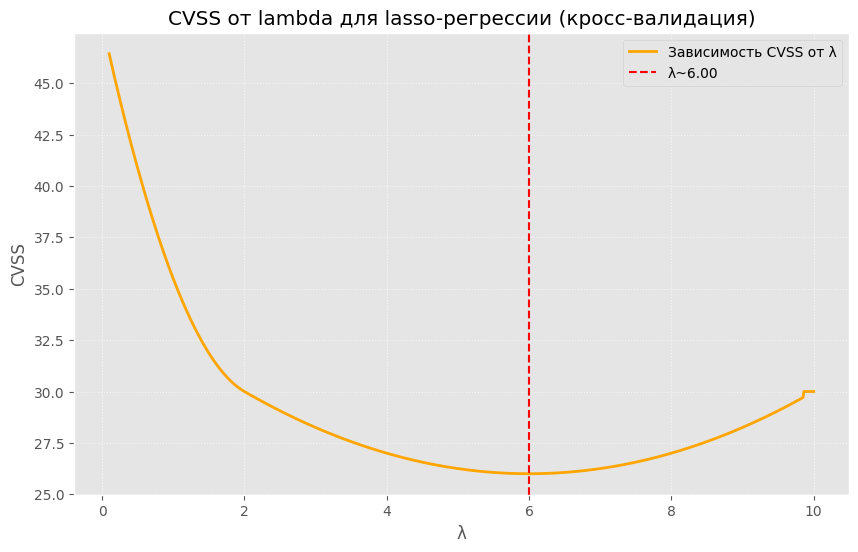

In [75]:
N = len(Y)
lambdas = np.linspace(0.1, 10, 1000)
CVSS = np.zeros(len(lambdas))

for idx, a in enumerate(lambdas):
    cur_cvss = 0
    for i in range(N):
        PSI_train = np.delete(PSI, i, axis=0)
        Y_train = np.delete(Y, i, axis=0)
        PSI_test = PSI[i]
        Y_test = Y[i]  
        a_corrected = a / (2*(N - 1))
        lasso = skl.Lasso(alpha=a_corrected, fit_intercept=False, max_iter=10000).fit(PSI_train, Y_train)
        prediction = np.dot(lasso.coef_, PSI_test)
        cur_cvss += (Y_test - prediction) ** 2
        
    CVSS[idx] = cur_cvss

min_index = np.argmin(CVSS)
alpha_opt_cv = lambdas[min_index]
min_cvss = CVSS[min_index]

print(f'λ_opt (по кросс-валидации): {alpha_opt_cv:.4f}')
plt.figure(figsize=(10, 6))
plt.plot(lambdas, CVSS, label='Зависимость CVSS от λ', color='orange', linewidth=2)
plt.axvline(x=alpha_opt_cv, color='red', linestyle='--', label=f'λ~{alpha_opt_cv:.2f}')
plt.title('CVSS от lambda для lasso-регрессии (кросс-валидация)')
plt.xlabel('λ')
plt.ylabel('CVSS')
plt.legend()
plt.grid(True, linestyle=':', alpha=0.7)
plt.show()